In [239]:
from pathlib import Path
import pandas as pd


# cargar raiz del proyecto
cwd = Path.cwd()
#print("cwd:", cwd)

#leer el dataset
dataset = pd.read_csv(cwd.parent / "data/auto_mpg.csv")
dataset.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [240]:
#tamano del dataset

print(f"Tamaño del dataset: \n{dataset.shape[0]} filas\n {dataset.shape[1]} columnas")


Tamaño del dataset: 
398 filas
 8 columnas


In [241]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [242]:
#ver las filas con valores nulos
dataset[dataset.isna().any(axis=1)]

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
32,25.0,4,98.0,NaN,2046.0,19.0,71,1
126,21.0,6,200.0,NaN,2875.0,17.0,74,1
330,40.9,4,85.0,NaN,1835.0,17.3,80,2
336,23.6,4,140.0,NaN,2905.0,14.3,80,1
354,34.5,4,100.0,NaN,2320.0,15.8,81,2
374,23.0,4,151.0,NaN,3035.0,20.5,82,1


In [243]:
#borrar las filas con valores nulos
dataset = dataset.dropna()
#verificar que no hay valores nulos
print(f"Tamaño del dataset después de borrar valores nulos: \n{dataset.shape[0]} filas\n {dataset.shape[1]} columnas")
dataset.isna().sum()

Tamaño del dataset después de borrar valores nulos: 
392 filas
 8 columnas


MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [244]:
#significado de la columna Origin
""" columna: 1 japon
    columna: 2 usa
    columna: 3 europa
"""
dataset.Origin.value_counts()


Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [245]:
#ejemplo con map para cambiar los valores de la columna Origin


dataset["Origin"] = dataset["Origin"].map(
    {   
        1: "USA", 
        2: "Europe", 
        3: "Japan",
    },
)
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA


In [246]:
#creacion de dummies para la columna Origin
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [247]:
# Particionamiento de los datos en features y labels
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)


c:\Users\santiago\Desktop\unal\analitica predictiva\std-santiago-ramos-galvis\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\santiago\Desktop\unal\analitica predictiva\std-santiago-ramos-galvis\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\santiago\Desktop\unal\analitica predictiva\std-santiago-ramos-galvis\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\santiago\Desktop

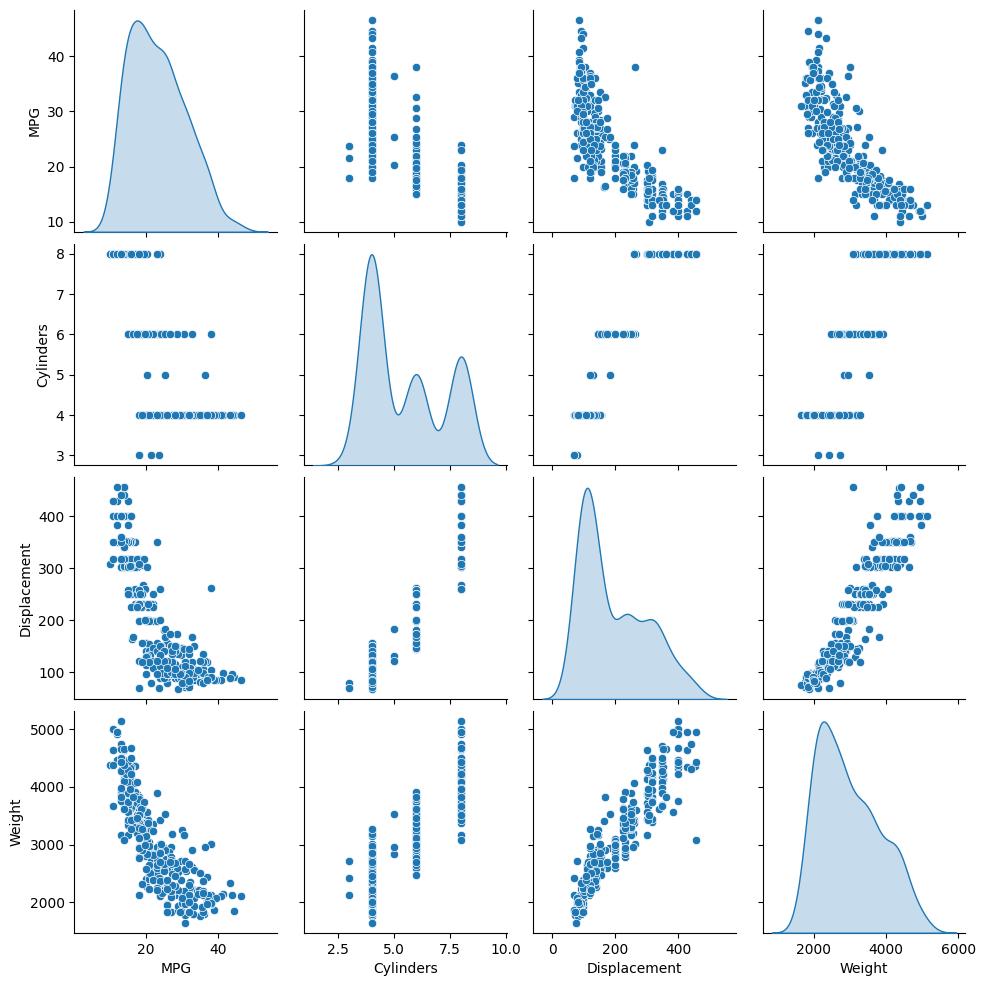

In [248]:
import seaborn as sns

graph=sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)
print(graph)

In [249]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [250]:
# Particionamiento de los datos en features y labels
train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")


In [251]:
#estandarizacion de los datos
train_dataset.describe().transpose()[["mean", "std"]]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [252]:
# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]



,mean,std
MPG,-2.206303e-16,1.001596
Cylinders,2.022444e-16,1.001596
Displacement,7.990777e-17,1.001596
Horsepower,-1.980016e-17,1.001596
Weight,-9.051500e-17,1.001596
Acceleration,-5.275327e-16,1.001596
Model Year,9.419217e-16,1.001596
Europe,3.394312e-17,1.001596
Japan,2.828594e-18,1.001596
USA,1.697156e-17,1.001596


In [253]:
# Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)



In [254]:
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)


LinearRegression()

In [255]:
# Intercepto
horsepower_model.intercept_

23.31050955414013

In [256]:
# Coeficientes
horsepower_model.coef_

array([-5.89948889])

In [257]:
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()

,Horsepower
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0


In [258]:
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]



array([39.57626034, 39.42115555, 39.26605075, 39.11094596, 38.95584117])

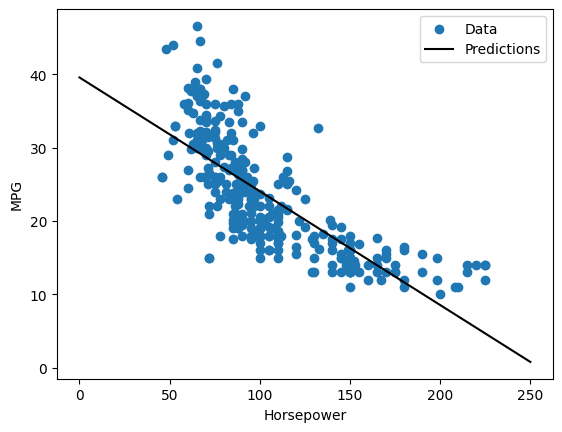

In [259]:
# grafica de los datos y la predicción
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
    
plot_horsepower(x, y)

In [260]:
#prediccion de los datos de prueba y calculo del error cuadratico medio
from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 20.829300555790315}

In [261]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# tus datos ya preparados: X_scaled (features escaladas) y y_true (MPG original)

modelos = {
    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=0),
    "SVR": SVR(C=1.0),
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=2000, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_scaled, y_true)
    y_pred = modelo.predict(X_scaled)
    mse = mean_squared_error(y_true, y_pred)
    resultados[nombre] = mse
    print(f"{nombre:20s}  MSE: {mse:.4f}")

mejor = min(resultados, key=resultados.get)
print(f"\nMejor modelo: {mejor} con MSE {resultados[mejor]:.4f}")

DecisionTree          MSE: 4.7443
RandomForest          MSE: 1.0092
SVR                   MSE: 9.3943
MLP                   MSE: 2.2019
GradientBoosting      MSE: 2.1867

Mejor modelo: RandomForest con MSE 1.0092


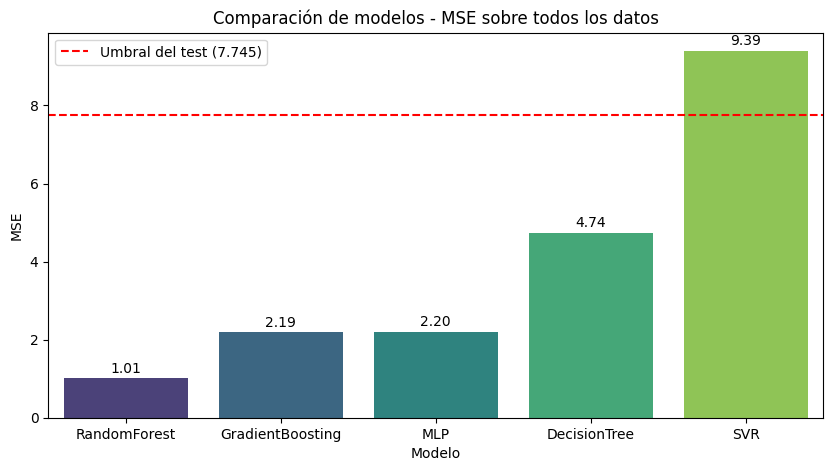

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

# resultados del diccionario anterior (nombre -> mse)
df_resultados = pd.DataFrame(
    list(resultados.items()), columns=["Modelo", "MSE"]
).sort_values("MSE")

plt.figure(figsize=(10, 5))
bars = sns.barplot(x="Modelo", y="MSE", data=df_resultados, palette="viridis")

plt.axhline(7.745, color="red", linestyle="--", label="Umbral del test (7.745)")
plt.title("Comparación de modelos - MSE sobre todos los datos")
plt.ylabel("MSE")
plt.legend()

# etiquetas con el valor exacto encima de cada barra
for bar, mse in zip(bars.patches, df_resultados["MSE"]):
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{mse:.2f}",
        ha="center",
        fontsize=10,
    )

plt.show()

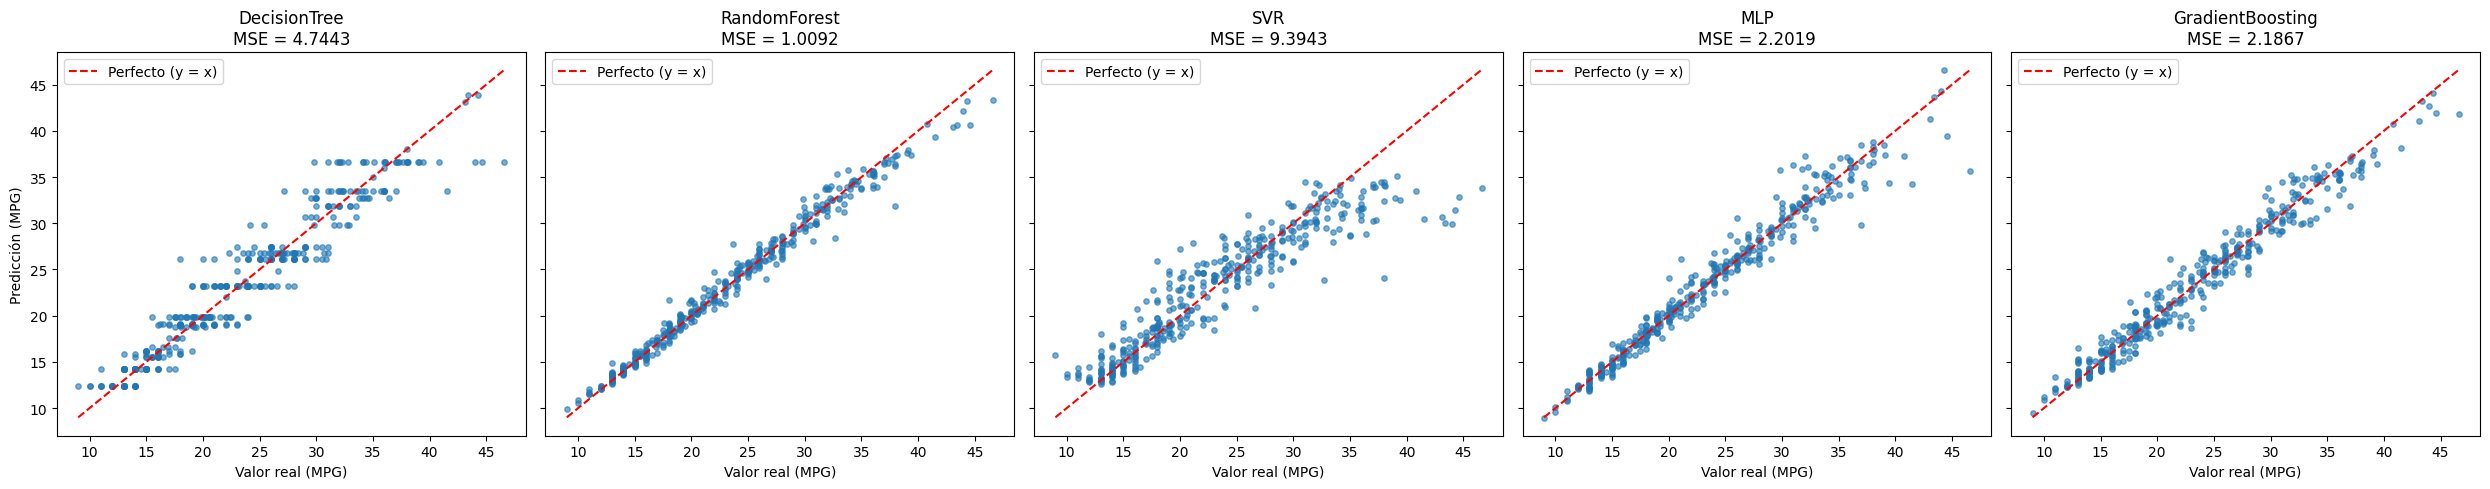

In [263]:
import matplotlib.pyplot as plt

n = len(modelos)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharex=True, sharey=True)

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_scaled)

    # puntos real vs real (line = perfecto) y real vs predicho
    ax.scatter(y_true, y_pred, alpha=0.6, s=15)
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()],
            "r--", label="Perfecto (y = x)")

    mse = mean_squared_error(y_true, y_pred)
    ax.set_title(f"{nombre}\nMSE = {mse:.4f}")
    ax.set_xlabel("Valor real (MPG)")
    ax.legend()

axes[0].set_ylabel("Predicción (MPG)")
plt.tight_layout()
plt.show()